# 04. PyTorch Custom Datasets Video Notebook

We ´ve used some datasets with PyTorch before.

But how do you get tour own data into PyTorch?

One of the ways to do so is via: custom datasets.

This section of this course is from Zero to Matery - PyTorch DeepLearning course. In here you will find my personal keynotes :)

## Domain libraries

Depending on what you´re working on, vision, text, audio, recomendation, you'll want to look into each of PyTorch domain libraries for existing data loading functions and customizable loading functions.

**Resources:**
* Book version of the course materials for 04: https://www.learnpytorch.io/04_pytorch_custom_datasets/

* Ground truth version of notebook 04: https://github.com/mrdbourke/pytorch-deep-learning/blob/main/04_pytorch_custom_datasets.ipynb

In [ ]:
%cd /content/drive/MyDrive/Ideas/PyTorch_DeepLearning/04_PyTorch_Custom_Datasets

/content/drive/MyDrive/Ideas/PyTorch_DeepLearning/04_PyTorch_Custom_Datasets


## 0. Importing PyTorch and setting up device-agnostic code

In [ ]:
import torch
from torch import nn

# Note: PyTorch 1.10.0 + is requiered for this course
torch.__version__

'2.8.0+cu126'

In [ ]:
# Set up device-agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## 1. Get Data

Our dataset is a subset of the Food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing)

Our data set starts with 3 classes of food and only 10% of the images(75 training, 25 testing).

Why do this?

When starting out ML projects, it's important to try things on a small scale and the increase the scale when necessary.

The whole point is to speed up how fast you can experiment.

In [ ]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# if the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
  print(f'{image_path} directory already exists...skipping download')
else:
  print(f'{image_path} does not exist, creating one...')
  image_path.mkdir(parents = True, exist_ok = True)

# Download pizza, steak and sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f: # this is the file that we are trying to open
  request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
  print('Downloading pizza, steak, sushi data...')
  f.write(request.content)

# Unzip piza, steak, sushi data
with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
  print('Unzipping pizza, steak and sushi data...')
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exists...skipping download
Unzipping pizza, steak and sushi data...


We want to convert the pictures into Tensors using PyTorch

Becoming One With the Data (Part 1): Exploring the Data Format

## 2. Becoming one with the data (data preparation and data exploration)

In [ ]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

In [ ]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'


In [ ]:
# Setup train and testing paths
train_dir = image_path / 'train'
test_dir = image_path / 'test'

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

video: Becoming One With the Data (Part 2): Visualizing a Random Image

### 2.1 Visualizing and image

Let's write some code to:
1. Get all of the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name using 'pathlib.Path.parent.stem'
4. Since we're working with images, let's open the iamge with Python's PIL
5. We'll show the image and print metadata

In [ ]:
image_path

PosixPath('data/pizza_steak_sushi')

data/pizza_steak_sushi/test/steak/673127.jpg
Random Image path: data/pizza_steak_sushi/test/steak/673127.jpg
Image class: steak
Image height: 512
Image width: 512


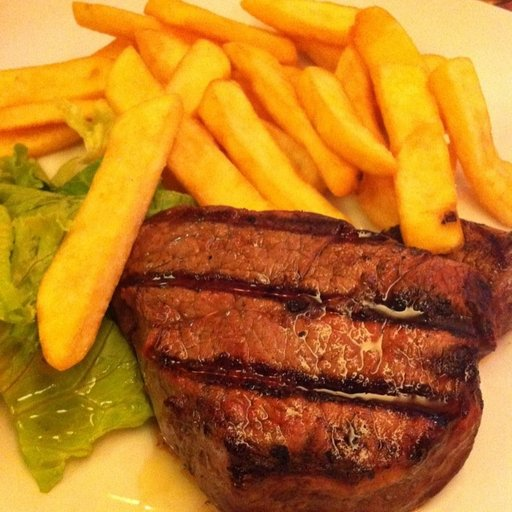

In [ ]:
import random
from PIL import Image

# Set seed
random.seed(91)

# 1. Get all image paths
image_path_list = list(image_path.glob('*/*/*.jpg'))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)

print(random_image_path)

# 3. Get image class from path name (the image class is the name of directorywhere the image is stored)
image_class = random_image_path.parent.stem
image_class

# 4. Open iamge
img = Image.open(random_image_path)

# 5. Print metadata
print(f'Random Image path: {random_image_path}')
print(f'Image class: {image_class}')
print(f'Image height: {img.height}')
print(f'Image width: {img.width}')
img

Becoming One With the Data (Part 3): Visualizing a Random Image with Matplotlib

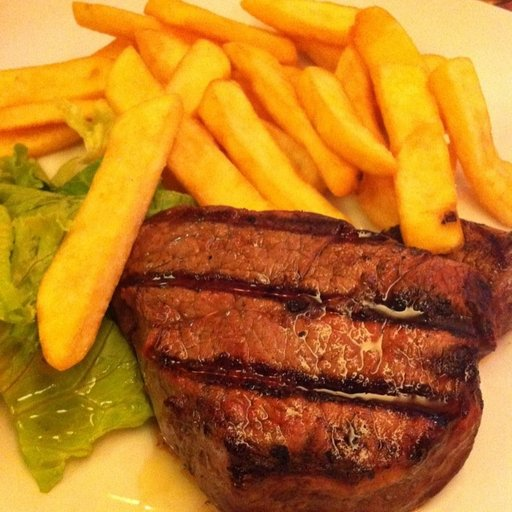

In [ ]:
# Visualize an image with matplotlib...
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

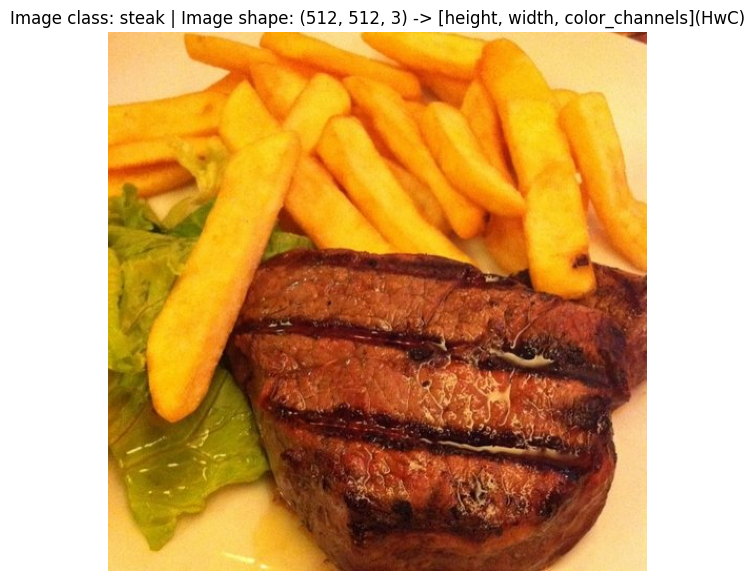

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize = (10, 7))
plt.imshow(img_as_array)
plt.title(f'Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels](HwC)')
plt.axis(False)
# PyTorch works with the color channels at first, we can manipualate those dimension

In [ ]:
print(img_as_array)

[[[255 191 107]
  [253 188 104]
  [253 188 106]
  ...
  [119  43  20]
  [118  40  17]
  [120  42  19]]

 [[255 194 110]
  [255 191 107]
  [254 189 107]
  ...
  [118  38  15]
  [132  50  28]
  [145  63  41]]

 [[253 189 102]
  [251 187 100]
  [249 187 102]
  ...
  [143  55  35]
  [157  66  47]
  [165  74  53]]

 ...

 [[247 208 103]
  [246 207 102]
  [249 210 107]
  ...
  [255 228 161]
  [254 227 160]
  [251 224 157]]

 [[251 212 107]
  [251 212 107]
  [252 213 110]
  ...
  [255 228 161]
  [254 227 160]
  [251 224 157]]

 [[251 212 107]
  [250 211 106]
  [250 211 108]
  ...
  [254 227 160]
  [253 226 159]
  [250 223 156]]]


video: Transforming Data (Part 1): Turning Images Into Tensors

## 3. Transforming data

Before we can use our image data with PyTorch:

1. Turn your target data into tensors (in our case, numerical representation of our images).

2. Turn it into a 'torch.utils.data.Dataset' and subsequently a 'torch.utils.data.DataLoader', we'll call these 'Dataset' and 'Dataloader'


The transform parameter: we do some transform in our data when we load it.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with torchvision.transforms

Transforms help you get your images ready to be used with model/perform data augmentantion - https://docs.pytorch.org/vision/0.9/transforms.html

In [ ]:
# write a transform for image
data_transform = transforms.Compose([
    # Resize our images to 64 X 64
    transforms.Resize(size = (64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p = 0.5), # 50% of the timean image would get flip
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # H * W * C -> C * H * W
])

In [ ]:
data_transform(img).shape
data_transform(img).dtype

torch.float32

Transforming Data (Part 2): Visualizing Transformed Images

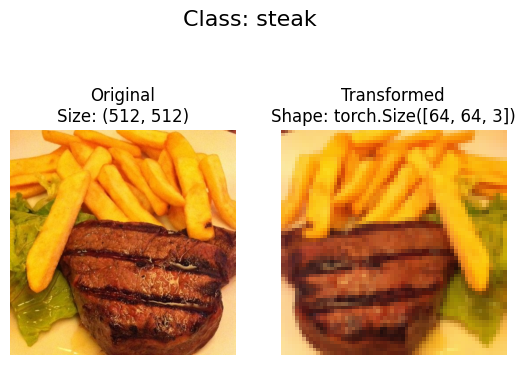

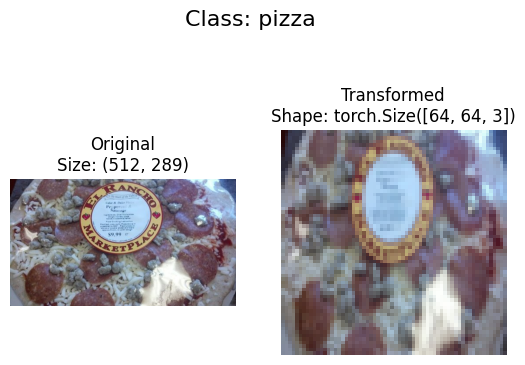

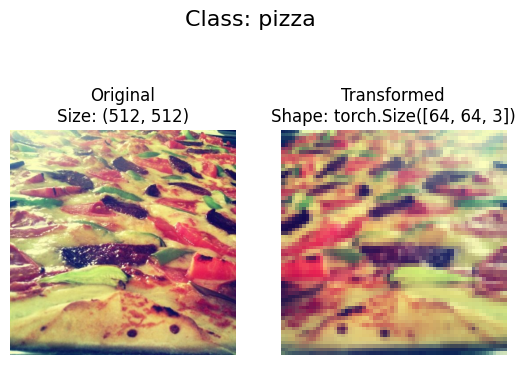

In [ ]:
# Visualize what it looks like if we plot a number of transform images
def plot_transformed_images(image_paths: list, transform, n = 3, seed = None):
  """
  Selects random images from a path of images and loads/transforms then
  plots the original vs transformed version.
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k = n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows = 1, ncols = 2)
      ax[0].imshow(f)
      ax[0].set_title(f'Original\nSize: {f.size}')
      ax[0].axis(False)

      # Transform and plot target image
      transformed_image = transform(f).permute(1, 2, 0) # note we will need to change shape for matplotlib (C, H, W) -> (H, W, C)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f'Transformed\nShape: {transformed_image.shape}')
      ax[1].axis(False)

      fig.suptitle(f'Class: {image_path.parent.stem}', fontsize = 16)

plot_transformed_images(image_paths = image_path_list,
                        transform = data_transform,
                        n = 3,
                        seed = 91)

Why we doing this?

We have less information encoded on the right images. So, our model will be able to compute faster. However we may loss some performance because there is lees information encoded than the original.


Loading All of Our Images and Turning Them Into Tensors With ImageFolder

## 4. Option 1: Loading image data using ImageFolder

We are trying to see how we can use ImageFolder to load all of our custome data into tensor.

We can load image classification data using torchvision.datasets.ImageFolder:

https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder

In [ ]:
# Use ImageFolder to create dataset(s)
# We are using image folder because we have the labels in the folder that the pictures have been saved
from torchvision import datasets
train_data = datasets.ImageFolder(root = train_dir,
                                  transform = data_transform, # a transform for the data
                                  target_transform = None) # a transform for the label/target

test_data = datasets.ImageFolder(root = test_dir,
                                 transform = data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [ ]:
# Get class names list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the length of our dataset
len(train_data), len(test_data)

(225, 75)

In [ ]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [ ]:
img, class_names[0]

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>, 'pizza')

Visualizing a Loaded Image From the Train Dataset

In [ ]:
# Index on the train_data Dataset to get a single image and label
# This is going to give us an image tensor
img, label = train_data[0][0], train_data[0][1]
print(f'Image tensor:\n {img}')
print(f'Image shape: {img.shape}')
print(f'Image datatype: {img.dtype}')
print(f'Image Label: {label}')
print(f'Name: {class_names[label]}')
print(f'Label datatype:{type(label)}')

Image tensor:
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute: torch.Size([64, 64, 3]) -> [hight, width, color_channels]


Text(0.5, 1.0, 'pizza')

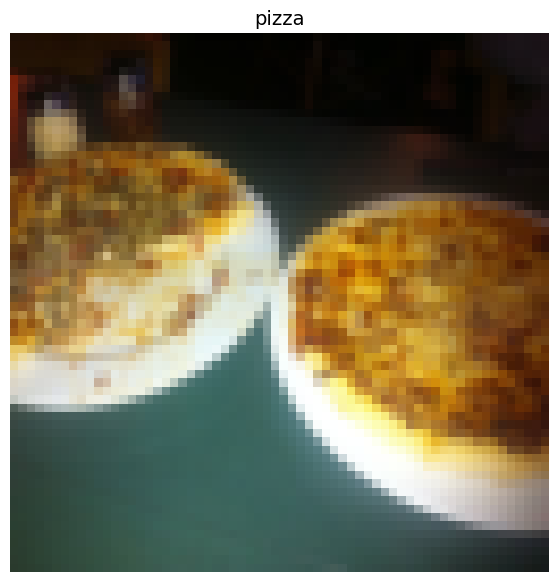

In [ ]:
# Plot it using matplotlib
# Rearrange the order dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes
print(f'Original shape: {img.shape} -> [color_channels, height, width]')
print(f'Image permute: {img_permute.shape} -> [hight, width, color_channels]')

# Plot the image
plt.figure(figsize = (10, 7))
plt.imshow(img_permute)
plt.axis('off')
plt.title(class_names[label], fontsize = 14)

Turning Our Image Datasets into PyTorch DataLoaders

### 4.1 Turn loaded images into 'DataLoader's'

A 'DataLoader' is going to help us turn our 'Dataset's' into iterables and we can customize the 'batch_size' so our model can see 'batch_size' images at a time.

In [ ]:
# See the memory we have
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Turn train and test datasets into DataLoader's
# DataLoader is going to add a abtch dimension
from torch.utils.data import DataLoader
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              num_workers = os.cpu_count(), # How many cpu core are we going to use
                              shuffle = True) # We dont want that the model recognize any order on the training data

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = False)

# We will get two instances
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7ba48ccccc50>,
 <torch.utils.data.dataloader.DataLoader at 0x7ba459ec73b0>)

In [ ]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [ ]:
img, label = next(iter(train_dataloader))

# Data Loader basically is going to add a batch dimension
# Batch size will now be 1, you can change the batch size if you like
print(f'Image shape: {img.shape} -> [batch_size, color channels, height. width]')
print(f'Label shape: {label.shape}')

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color channels, height. width]
Label shape: torch.Size([1])


Creating a Custom Dataset Class in PyTorch High Level Overview

## 5. Option 2: Loading Image Data with a Custom 'Dataset'

1. Want to be able to load images from file
2. Want to be able to get class names from Dataset
3. Want to be able to get classes as dictionary from the Dataset

Pros:
 * Can create a 'Dataset' out of almost everything

 * Not limited to PyTorch pre-built 'Dataset' functions

 Cons:
 * Even though you could create 'Dataset' out of almost anything, it doesn't mean it will work...

 * Using a custom 'Dataset' often results in us writing more code, wich could be prone to errors or perfomance issues

In [ ]:
import os
import pathlib # this is for working with file paths
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms # Transoform the images into tensors
from typing import Tuple, Dict, List

In [ ]:
# Instance of torchvision.datasets.ImageFolder()

train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

Creating a Helper Function to Get Class Names From a Directory

### 5.1 Creating a helper function to get class names

We want a function to:
1. Get the class names using 'os.scandir()' to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren´t found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dict and a list an return them.

In [ ]:
# Setup path directory
# We will use the train folder as an example to begin with
target_directory = train_dir
print(f'Target dir: {target_directory}')

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [ ]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]: # It will return a list and a dictionary
  """Finds the class folder names in a target dorectory."""
  # 1. Get the class names by scanning the taarget directory
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if classnames could not be found
  if not classes:
    raise FileNotFoundError(f'Could not find any classes in {directory}...please check file structure.')

  # 3. Create a dictionary of index labels (computers prefer numbers rather than strings as labels)
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
  return classes, class_to_idx

In [ ]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

Writing a PyTorch Custom Dataset Class from Scratch to Load Our ImagesMM

### 5.2 Create a custom 'Dataset' to replicate 'ImageFolder'

To create our own custom dataset, we want to:

1. Subclass 'torch.utils.data.Dataset'
2. Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform our data.
3. Create several attributes:
  * paths - paths of our images
  * transform - the transform we'd like to use
  * classes - a list of the target cclasses
  * class_to_idx -a dict of thetarget classes mapped to integer labels
4. Create a function to 'load_images()', this function will open an iamge.
5. Overwrite the '__len()__' method to return the length of our dataset
6. Overwrite the '__getitem()__' method to return a given sample when passed an index

In [ ]:
train_dir
list(pathlib.Path(train_dir).glob("*/*.jpg"))
paths = list(pathlib.Path(train_dir).glob("*/*.jpg"))
paths[10]
paths[10].parent.name

'pizza'

In [ ]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset

# 1.Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset): # All the functions that contains torch.utils.data.Dataset we are going to get for our own custom class
  # 2. Initialize our custom dataset
  def __init__(self,
               targ_dir: str,
               transform = None):
    # 3. Create class attributes
    # Get all of the images paths
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transform
    self.transform = transform
    # Createclasses and class_to_idx attribute
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Create a function to load images
  def load_image(self, index: int) -> Image.Image:
    "Opens an image via a path and returns it."
    image_path = self.paths[index]
    return Image.open(image_path)
  # 5. Overwrite __len__()
  def __len__(self) -> int:
    "Returns the total number of samples."
    return len(self.paths)

  # 6. Overwrite __getitem__() method to return a particular sample
  def __getitem__(self, index: int) ->Tuple[torch.Tensor, int]:
    "Returns one sample of data, data amd label (X, y)."
    img = self.load_image(index)
    class_name = self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

    # Transform if necessary
    if self.transform:
      return self.transform(img), class_idx # return data, label(X, y)
    else:
      return img, class_idx # return untransformed image and label

Compare Our Custom Dataset Class to the Original ImageFolder Class

In [ ]:
# Create a trasnform
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p= 0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor() # we don't manipulate the data
])

In [ ]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir = train_dir,
                                      transform = train_transforms)

test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                     transform = test_transforms)

In [ ]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7ba45b7aa120>,
 <__main__.ImageFolderCustom at 0x7ba48c1eae70>)

In [ ]:
len(train_data), len(train_data_custom)

(225, 225)

In [ ]:
len(test_data), len(test_data_custom)

(75, 75)

In [ ]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [ ]:
# Check for equality between original ImageFolder Dataset and ImageFolderCustom Dataset
print(train_data.classes==train_data_custom.classes)
print(test_data.classes==test_data_custom.classes)

True
True


Writing a Helper Function to Visualize Random Images from Our Custom Dataset

### 5.3 Create a function to display random images

1. Take in a 'Dataset' and a number of other parameters such as class names and how many images to visualize.

2. To prevent the display getting out of hand, let's cap the number of iamges to see at 10.

3. Set the random seed for reproducibility

4. Get a list of random sample indexes from the target dataset

5. Setup a matplotlib plot.

6. Loop through the random sample indexes and plot them with matplotlib

7. Make sure the dimensions of our images line up with matplotlib (HWC)

In [ ]:
random.sample(range(len(train_data_custom)), k = 10)

[102, 117, 216, 200, 190, 112, 119, 211, 65, 62]

In [ ]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str]  = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  # 2. Adjust display if n is too high
  if n > 10:
    n = 10
    display_shape = False
    print(f"For display, purposes, n shouldn't be larger than 10, setting and removing shape display.")

  # 3. Set the seed
  if seed:
    random.seed(seed)

  # 4. Get random sample indexes
  random_samples_idx= random.sample(range(len(dataset)), k = n)

  # 5. Setupplot
  plt.figure(figsize = (16, 8))

  # 6. Loop through random indexes and plot them with matplotlib
  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    # 7. Adjust tensor dimensions for plotting
    targ_image_adjust = targ_image.permute(1, 2, 0) # [color_channels, height, width] -> [height, width, color channels]

    # Plot adjusted
    plt.subplot(1, n, i + 1)
    plt.imshow(targ_image_adjust)
    plt.axis('off')
    if classes:
      title = f'Class: {classes[targ_label]}'
      if display_shape:
        title = title + f'\nShape: {targ_image_adjust.shape}'
      plt.title(title)

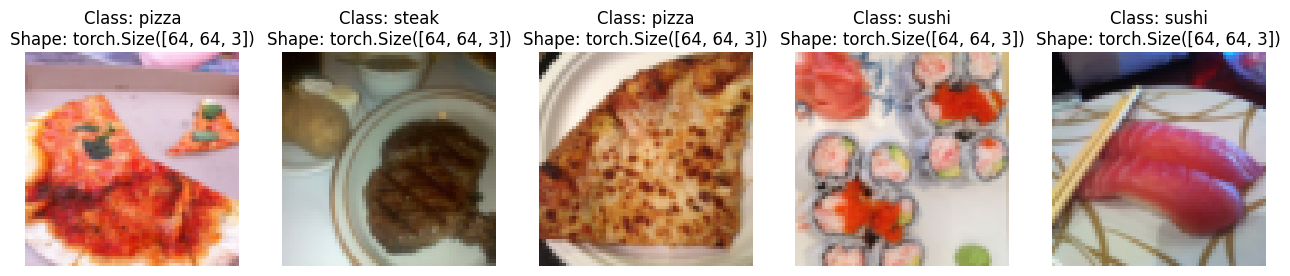

In [ ]:
# Display random images from the ImageFolder created Dataset
display_random_images(train_data,
                      n = 5,
                      classes = class_names,
                      seed = 91)

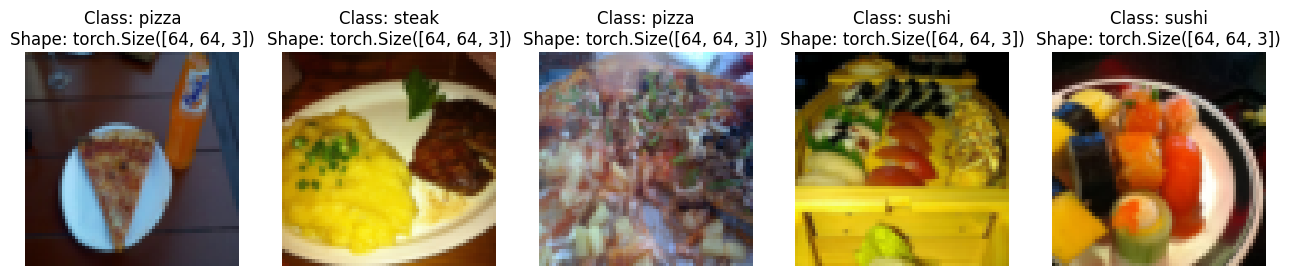

In [ ]:
# Display random images from the ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      n = 5,
                      classes = class_names,
                      seed = 91)

Turning Our Custom Datasets Into DataLoaders

### 5.4 Turn Custom loaded images into DataLoader's

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                     batch_size = BATCH_SIZE,
                                     num_workers = NUM_WORKERS,
                                     shuffle= True)

test_dataloader_custom = DataLoader(dataset =test_data_custom,
                                    batch_size = BATCH_SIZE,
                                    num_workers = NUM_WORKERS,
                                    shuffle = False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7ba477f46750>,
 <torch.utils.data.dataloader.DataLoader at 0x7ba45c892c30>)

In [ ]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))

# Print out the shapes
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

Exploring State of the Art Data Augmentation With Torchvision Transforms

## 6. Other forms of transforms (data augmentation)

Data augementation is the process of artificially adding diversity to your training data so that our images becoming harder for our model to learn or it get a chance to view the same image from different perspective so that when you use your image classificiation model in practice it seen the same sort iamge but from different angles

In the case of image data, this may mean applying various iamge transofrmation to the training images.

This practice hopefully results in a model that's more generalizable to unseen data.

Let's take a look at one particular type of data augemntation used to train PyTorch vision models to state of the art levels...

In [ ]:
# Let's look at trivialaugment - https://docs.pytorch.org/vision/main/generated/torchvision.transforms.TrivialAugmentWide.html
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins = 31), # intensity of rotation
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.ToTensor()
])

In [ ]:
# Get all the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/pizza/540882.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/714866.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2236338.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/3092704.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/309892.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/344397.jpg')]

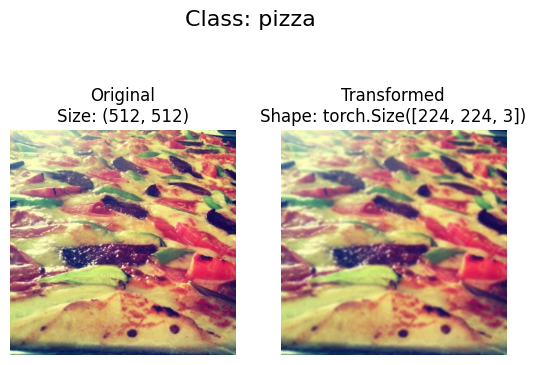

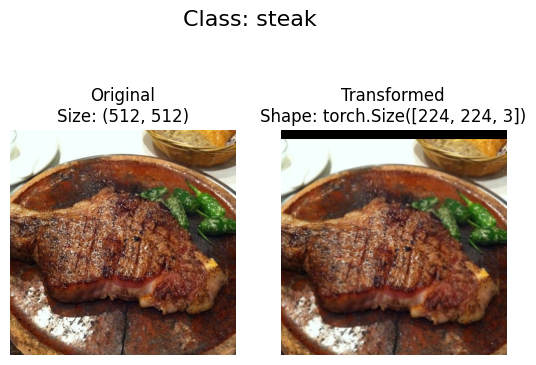

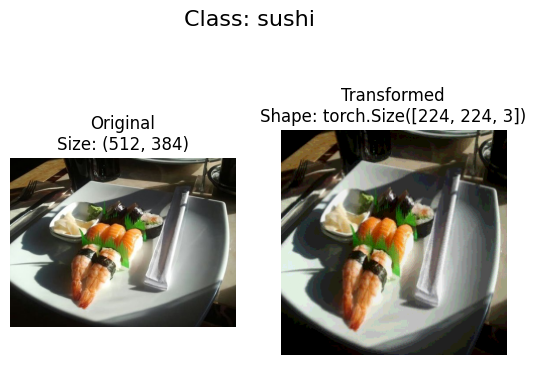

In [ ]:
# Plot random transformed images
plot_transformed_images(
    image_paths = image_path_list,
    transform = train_transform,
    n = 3,
    seed = None
)

Building a Baseline Model (Part 1): Loading and Transforming Data

## 7. Model 0: TinyVGG without data augmentation

LEt's replciate the tinyVGG architecture from the CNN Explainer website: https://poloclub.github.io/cnn-explainer/

### 7.1 Creating transforms and loading data Model 0

In [ ]:
# Create simple transform
# We want to load the images from the folders and turn them into tensors
simple_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor()
])

In [ ]:
# 1. Load and transform data
# we name it train_data_simple because with this we are not going to use data augmentation
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root = train_dir,
                                        transform = simple_transform)
test_data_simple = datasets.ImageFolder(root = test_dir,
                                        transform = simple_transform)

# 2. Turn datasets into DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of works
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

# Create DataLoader's
train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = True,
                                     num_workers = NUM_WORKERS)

test_dataloader_simple = DataLoader(dataset= test_data_simple,
                                    batch_size = BATCH_SIZE,
                                    shuffle = False,
                                    num_workers = NUM_WORKERS)

Building a Baseline Model (Part 2): Replicating Tiny VGG from Scratch

### 7.2 Create TinyVGG model class

In [ ]:
from torch import nn

In [ ]:
class TinyVGG(nn.Module):
  """
  Model architecture copying TinyVGG from CNN Explainer: https://poloclub.github.io/cnn-explainer/
  """
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride= 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride=1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride =2) # default stride value is same as kernel_size
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride= 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride=1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride =2) # default stride value is same as kernel_size
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units * 13 * 13,
                  out_features = output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)
    return x

In [ ]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape = 3, # number of color channels in our image data
                  hidden_units = 10,
                  output_shape = len(class_names)
                  ).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

Building a Baseline Model (Part 3): Doing a Forward Pass to Test Our Model Shapes

### 7.3 Try a forward pass on a single image (to test the model)

In [ ]:
# get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
# Try a forward pass
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4668e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9131e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6415e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3995e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.1665e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

Using the Torchinfo Package to Get a Summary of Our Model

### 7.4 Use 'torchinfo' to get an idea of the shapes going through our model

In [ ]:
# Install torch info, import if it's available
try:
  import torchinfo
except:
  !pip install torchinfo

from torchinfo import summary
summary(model_0, input_size = [1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

Creating Training and Testing loop Functions

### 7.5 Create train and test loops functions

* 'train_step()' - takes in a model and dataloader and trains the model on the dataloader.
* 'test_step()' - takes in a model and dataloader and evaluates the model on the dataloader

In [ ]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):
  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through dataloader data batches
  for batch, (X, y) in enumerate(dataloader):
    # Send data to the target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate accuracy metric
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
    train_acc += (y_pred_class==y).sum().item()/len(y_pred)

  # Adjust metrics to get the average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [ ]:
# Create a test step
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):
  # Put model in evalmode
  model.eval()

  # Setup test loss and test accuracy
  test_loss, test_acc = 0, 0

  # Turn on inference mode
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)

      # 2. Calculate the los
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate the accuracy
      test_pred_labels = test_pred_logits.argmax(dim = 1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

Creating a Train Function to Train and Evaluate Our Models

### 7.6 Creating a 'train()' function to combine 'train_step()' and 'test_step()'

In [ ]:
from tqdm.auto import tqdm

# 1. Create a train function that takes in various model parameters + optimizer + dataloaders + loss function
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device = device):

  # 2. Create empty results dictionary
  results = {'train_loss': [],
            'train_acc': [],
             'test_loss': [],
             'test_acc': []}

  # 3. Loop through and testing steps for number of epochs
  for epoch in range(epochs): # going to delete tqdm(range(epochs)) just for GitHub visualization
    train_loss, train_acc = train_step(model = model,
                                       dataloader = train_dataloader,
                                       loss_fn = loss_fn,
                                       optimizer = optimizer,
                                       device = device)

    test_loss, test_acc = test_step(model = model,
                                    dataloader = test_dataloader,
                                    loss_fn = loss_fn,
                                    device = device)

    # 4. Print pit what's happening
    print(f'Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}')

    # 5. Update results dictionary
    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)

  # 6. Return the filled results at the end of epochs
  return results

Training and Evaluating Model 0 With Our Training Functions

### 7.7 Train and evaluate model 0

In [ ]:
# Set random seed
# torch.manual_seed(91)
# torch.cuda.manual_seed(91)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape = 3, # number of color channel of pur target images
                  hidden_units = 10,
                  output_shape = len(train_data.classes)).to(device)

# Setup loss unction and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),
                             lr = 0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model = model_0,
                        train_dataloader = train_dataloader_simple,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f'Total training time: {end_time - start_time:.3f} seconds')

Epoch: 0 | Train loss: 1.0993 | Train acc: 0.4180 | Test loss: 1.1006 | Test acc: 0.1979
Epoch: 1 | Train loss: 1.1046 | Train acc: 0.2930 | Test loss: 1.1154 | Test acc: 0.1979
Epoch: 2 | Train loss: 1.0987 | Train acc: 0.2930 | Test loss: 1.1011 | Test acc: 0.1979
Epoch: 3 | Train loss: 1.0902 | Train acc: 0.3008 | Test loss: 1.0936 | Test acc: 0.1979
Epoch: 4 | Train loss: 1.0903 | Train acc: 0.3320 | Test loss: 1.0841 | Test acc: 0.2699
Total training time: 16.511 seconds


Plotting the Loss Curves of Model 0MM

### 7.8 Plot the loss curves of Model 0

A **loss curve** is a way of tracking your model's progress over time.

A godd guide for different loss curves can be seen here: https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves?hl=es-419

In [ ]:
# get the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):
  """Plots training curves of a results dictionary."""
  # Get the loss values of the results dictionary (training and test)
  loss = results['train_loss']
  test_loss = results['test_loss']

  # Get the accuracy values of the results dictionary (training and test)
  accuracy = results['train_acc']
  test_accuracy = results['test_acc']

  # Figure out how many epochs there were
  epochs = range(len(results['train_loss']))

  # Setup a plot
  plt.figure(figsize = (15, 7))

  # Plot the loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label = 'train_loss')
  plt.plot(epochs, test_loss, label = 'test_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot the accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label = 'train_accuracy')
  plt.plot(epochs, test_accuracy, label= 'test_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()

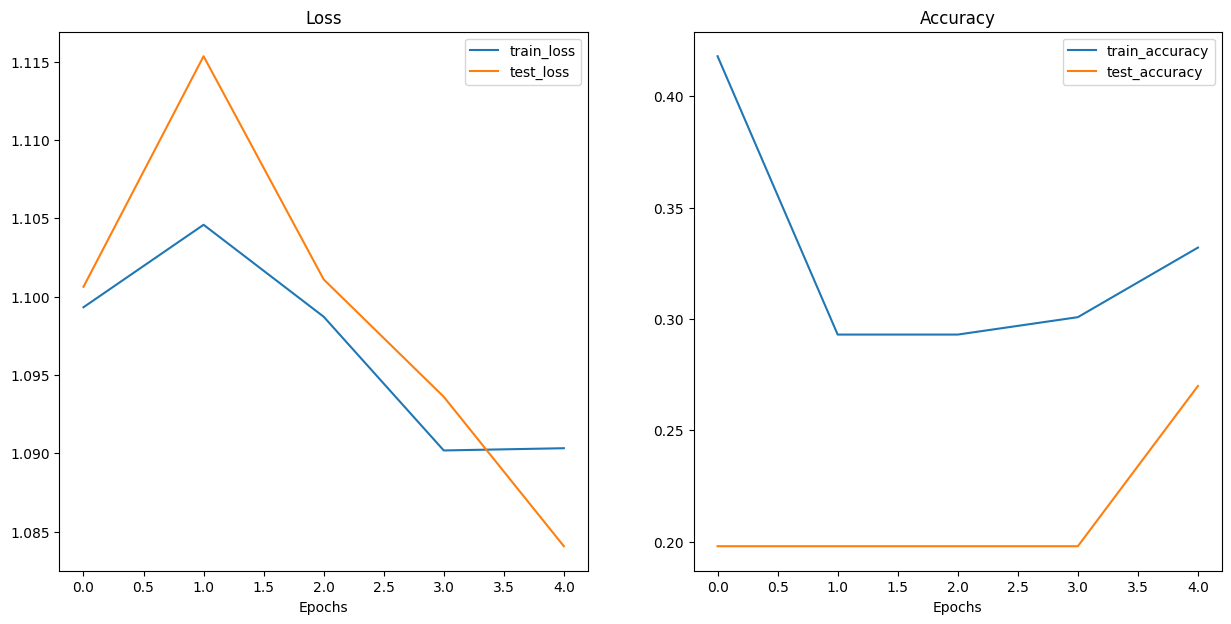

In [ ]:
plot_loss_curves(model_0_results)

Discussing the Balance Between Overfitting and Underfitting and How to Deal With Each

### 7.8.1 Plot_loss_curves (script)

In [ ]:
# Create a directory going_modular scripts
import os
if Path('going_modular').is_dir():
  print('Already created')
else:
  os.makedirs('going_modular')

Already created


In [ ]:
%%writefile going_modular/plot_loss_curves.py
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
  """Plots training curves of a results dictionary."""
  # Get the loss values of the results dictionary (training and test)
  loss = results['train_loss']
  test_loss = results['test_loss']

  # Get the accuracy values of the results dictionary (training and test)
  accuracy = results['train_acc']
  test_accuracy = results['test_acc']

  # Figure out how many epochs there were
  epochs = range(len(results['train_loss']))

  # Setup a plot
  plt.figure(figsize = (15, 7))

  # Plot the loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label = 'train_loss')
  plt.plot(epochs, test_loss, label = 'test_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot the accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label = 'train_accuracy')
  plt.plot(epochs, test_accuracy, label= 'test_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()

Overwriting going_modular/plot_loss_curves.py


## 8. What should an ideal loss curve look like?

https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves?hl=es-419

A loss curve is one of the most helpful ways to troubleshoot a model.

* Underfitting: When you loss could be lower

* Overfitting: Train loss is lower than Test loss

* Just right: Train and test loss similar

Creating Augmented Training Datasets and DataLoaders for Model 1

## 9. Model 1: TinyVGG with Data Augmentation

Now let's try another modelling experiment this time using the same model as before with some data augmentation.

This is one way of dealing with overfitting.

### 9.1 Create transform withdata augmentation

In [ ]:
# Create training transform with TrivialAugment
from torchvision import transforms
train_transform_trivial = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins = 31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor()
])

### 9.2 Create train and test 'Dataset's' and 'DataLoader's' with data augmentation

In [ ]:
# Turn image folders into Datasets
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root = train_dir,
                                            transform = train_transform_trivial)

test_data_simple = datasets.ImageFolder(root = test_dir,
                                         transform = test_transform_simple)

In [ ]:
# Turn our Datasets into DataLoaders
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 91
NUM_WORKERS = os.cpu_count()

# torch.manual_seed(91)

train_dataloader_augmented = DataLoader(dataset = train_data_augmented,
                                        batch_size = BATCH_SIZE,
                                        shuffle = True,
                                        num_workers = NUM_WORKERS)

test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                    batch_size = BATCH_SIZE,
                                    shuffle = False,
                                    num_workers = NUM_WORKERS)

Constructing and Training Model 1

### 9.3 Construct and train model 1

This time we'll be using the same model architecture except this time we've augmented the training data.

In [ ]:
# Creae model_1 and send it to the target device
# torch.manual_seed(91)
model_1 = TinyVGG(input_shape = 3,
                  hidden_units = 10,
                  output_shape = len(train_data_augmented.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

Now we have got a model and DataLoaders, let's create a aloss function and an optimizer and call upon our train() function to train and evaluate our model.

In [ ]:
# Set random seeds
# torch.manual_seed(91)
# torch.cuda.manual_seed(91)

# Set the number of epochs
NUM_EPOCHS = 5

# Setup loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(),
                             lr = 0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model 1
model_1_results = train(model = model_1,
                        train_dataloader= train_dataloader_augmented,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS,
                        device = device)

# End the timer and print how long it took
end_time = timer()
print(f'Total training timer for model_1: {end_time - start_time:.3f} seconds')

Epoch: 0 | Train loss: 1.1072 | Train acc: 0.3197 | Test loss: 1.1070 | Test acc: 0.3333
Epoch: 1 | Train loss: 1.0962 | Train acc: 0.3470 | Test loss: 1.0966 | Test acc: 0.3600
Epoch: 2 | Train loss: 1.0926 | Train acc: 0.4746 | Test loss: 1.0922 | Test acc: 0.4400
Epoch: 3 | Train loss: 1.0902 | Train acc: 0.4720 | Test loss: 1.0870 | Test acc: 0.4800
Epoch: 4 | Train loss: 1.0790 | Train acc: 0.5177 | Test loss: 1.0785 | Test acc: 0.4000
Total training timer for model_1: 20.000 seconds


### 9.4 Plot the loss curves of model 1

A loss curve helps you evaluate your model performance over time

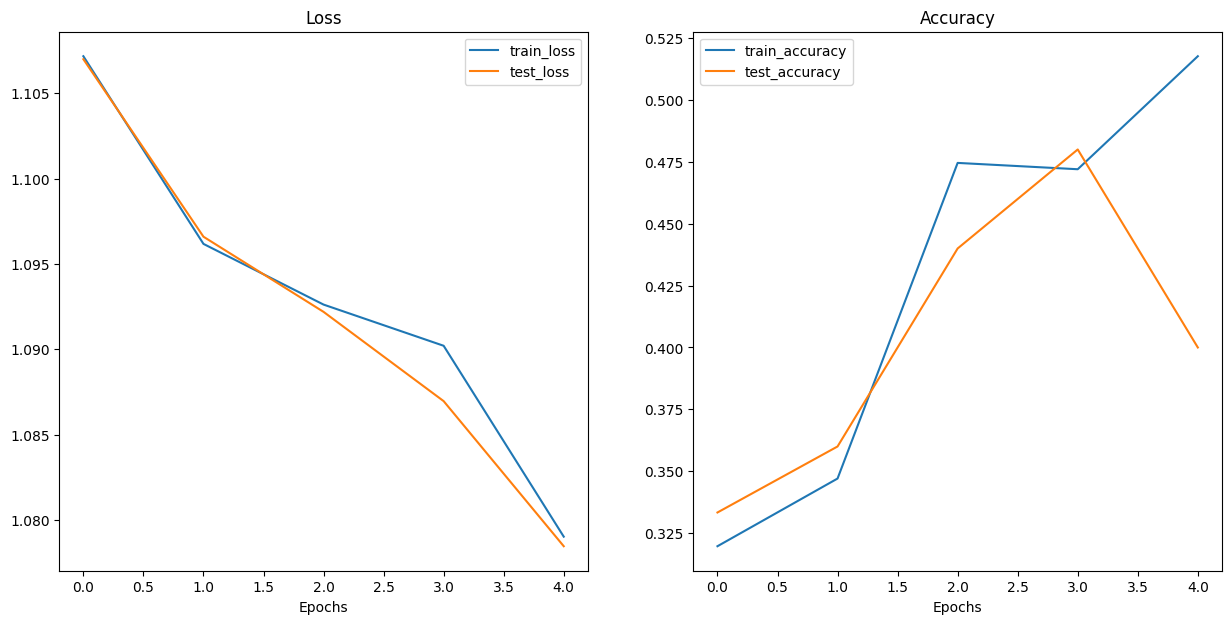

In [ ]:
plot_loss_curves(model_1_results)

Plotting the Loss Curves of All of Our Models Against Each Other

## 10. Compare model results

After evaluating our modelling experiments on their own, it's important to compare them to each other.

There's a few different ways to do this:
1. Hard coding
2. PyTorch + TensorBoard: https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html
3. Weights and Bias: https://wandb.ai/site/
4. MLFlow - https://mlflow.org/

In [ ]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_1_df

,train_loss,train_acc,test_loss,test_acc
0,1.107164,0.319704,1.106990,0.333333
1,1.096174,0.347048,1.096595,0.360000
2,1.092619,0.474572,1.092193,0.440000
3,1.090208,0.472016,1.086966,0.480000
4,1.079029,0.517676,1.078469,0.400000


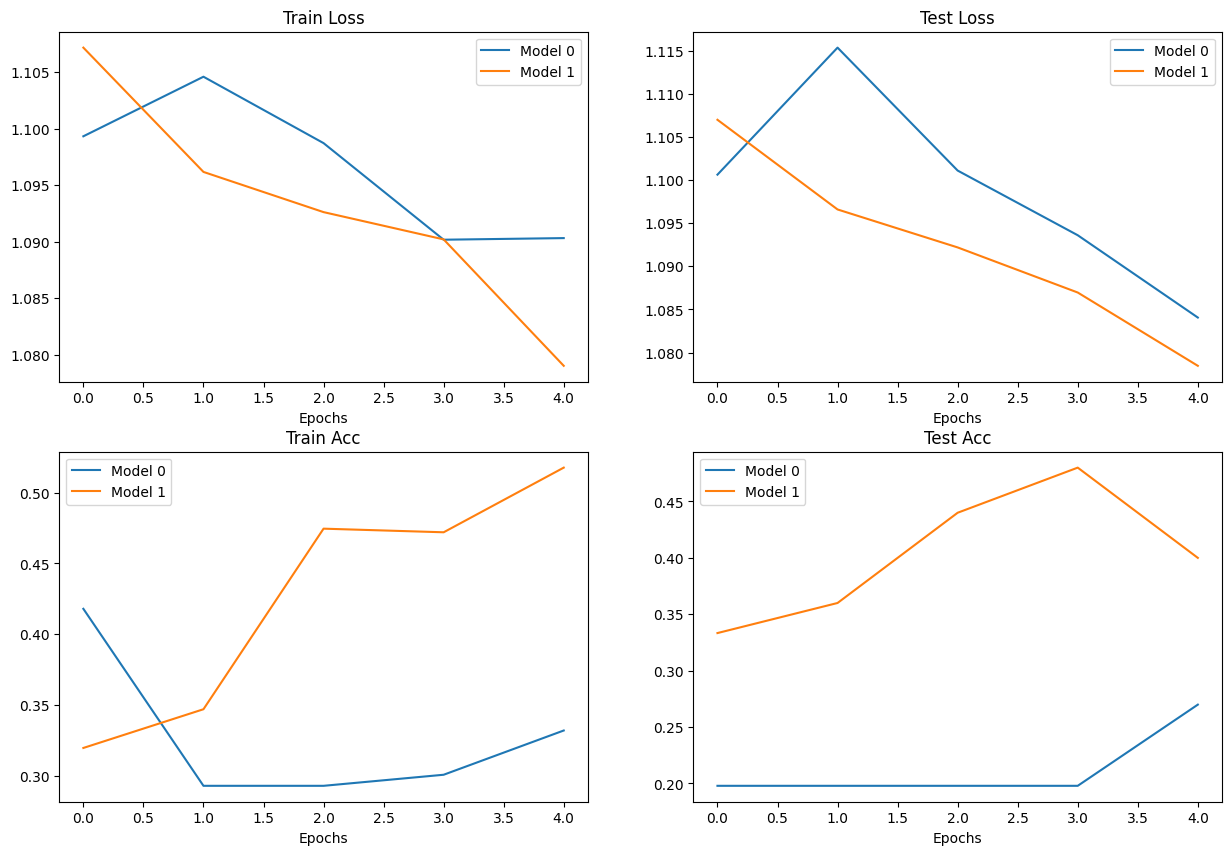

In [ ]:
# Setup a plot
plt.figure(figsize = (15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df['train_loss'], label = 'Model 0')
plt.plot(epochs, model_1_df['train_loss'], label = 'Model 1')
plt.title('Train Loss')
plt.xlabel('Epochs')
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df['test_loss'], label = 'Model 0')
plt.plot(epochs, model_1_df['test_loss'], label = 'Model 1')
plt.title('Test Loss')
plt.xlabel('Epochs')
plt.legend()

# Plot train acc
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df['train_acc'], label = 'Model 0')
plt.plot(epochs, model_1_df['train_acc'], label = 'Model 1')
plt.title('Train Acc')
plt.xlabel('Epochs')
plt.legend()

# Plot test acc
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df['test_acc'], label = 'Model 0')
plt.plot(epochs, model_1_df['test_acc'], label = 'Model 1')
plt.title('Test Acc')
plt.xlabel('Epochs')
plt.legend()

Predicting on Custom Data (Part 1): Downloading an Image

## 11. Making a prediction on a custom iamge

Although we've trained a model on custom data...how do you make a prediction on a sample/image that's not in either training or testing dataset.

In [ ]:
# Download custom iamge
import requests

# Setup custom image path
custom_image_path = data_path / '04-pizza-dad.jpeg'

# Fownload the iamge if it doesn't already exist
if not custom_image_path.is_file():
  with open(custom_image_path, 'wb') as f:
    # When downloading from GitHub, need to use the 'raw' file link
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/04-pizza-dad.jpeg?raw=true')
    print(f'Downloading {custom_image_path}...')
    f.write(request.content)
else:
  print(f'{custom_image_path} already exists, skipping downlaod...')

data/04-pizza-dad.jpeg already exists, skipping downlaod...


Predicting on Custom Data (Part2): Loading In a Custom Image With PyTorch

### 11.1 Loading in a custom image with PyTorch

We have to make sure our custom image is in the same format as the data our model was trained on.

* In tensor form with datatyp (torch.float 32)

* Of shape 64x64x3

* On the right device

We can read an image into PyTorch using - https://docs.pytorch.org/vision/0.19/generated/torchvision.io.read_image.html

In [ ]:
custom_image_path

PosixPath('data/04-pizza-dad.jpeg')

In [ ]:
import torchvision

# Read in custom image
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
print(f'Custom image tensor:\n {custom_image_uint8}')
print(f'Custom image shape: {custom_image_uint8.shape}')
print(f'Custom iamge datatype: {custom_image_uint8.dtype}')

Custom image tensor:
 tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)
Custom image shape: torch.Size([3, 4032, 3024])
Custom iamge data

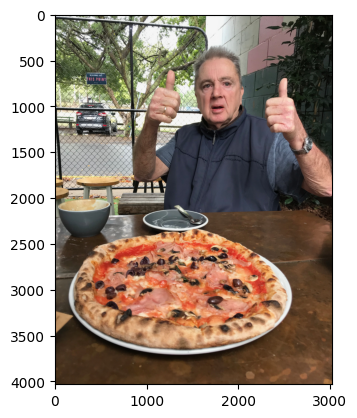

In [ ]:
plt.imshow(custom_image_uint8.permute(1, 2, 0))

Predicting on Custom Data (Part 3): Getting Our Custom Image Into the Right Format

### 11.2 Making a prediction on a custom image with a trained PyTorch model

In [ ]:
# Try to make prediction on an image in unit8 format
model_1.eval()
with torch.inference_mode():
  model_1(custom_image_uint8.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

Predicting on Custom Data (Part 3): Getting Our Custom Image Into the Right Format

In [ ]:
# Load in the image and convert to torch.float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 225.
custom_image

tensor([[[0.6844, 0.7689, 0.8044,  ..., 0.0933, 0.0800, 0.0622],
         [0.6489, 0.7333, 0.8044,  ..., 0.0933, 0.0800, 0.0667],
         [0.5511, 0.6489, 0.7644,  ..., 0.0800, 0.0756, 0.0667],
         ...,
         [0.3200, 0.2622, 0.2000,  ..., 0.6756, 0.6667, 0.6578],
         [0.2844, 0.2444, 0.1822,  ..., 0.6667, 0.6533, 0.6400],
         [0.2844, 0.2667, 0.2044,  ..., 0.6622, 0.6489, 0.6356]],

        [[0.7600, 0.8444, 0.8578,  ..., 0.0978, 0.0844, 0.0667],
         [0.7244, 0.8089, 0.8578,  ..., 0.0978, 0.0844, 0.0711],
         [0.6267, 0.7244, 0.8178,  ..., 0.0844, 0.0800, 0.0711],
         ...,
         [0.2444, 0.1867, 0.1244,  ..., 0.4756, 0.4622, 0.4578],
         [0.2089, 0.1689, 0.1067,  ..., 0.4800, 0.4622, 0.4533],
         [0.2089, 0.1911, 0.1289,  ..., 0.4756, 0.4622, 0.4489]],

        [[0.5289, 0.6133, 0.6533,  ..., 0.0756, 0.0622, 0.0444],
         [0.4933, 0.5778, 0.6444,  ..., 0.0756, 0.0622, 0.0489],
         [0.3867, 0.4933, 0.6044,  ..., 0.0622, 0.0578, 0.

In [ ]:
# Create transofmr pipeline to resize image
from torchvision import transforms

custom_image_transform = transforms.Compose([
    transforms.Resize(size = (64, 64))
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out the shapes
print(f'Original shapes: {custom_image.shape}')
print(f'Transformed shape: {custom_image_transformed.shape}')

Original shapes: torch.Size([3, 4032, 3024])
Transformed shape: torch.Size([3, 64, 64])


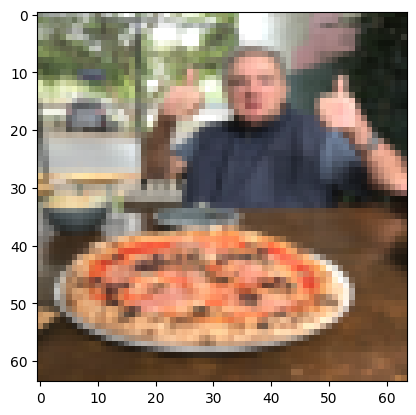

In [ ]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))
# we should consider increase the size of thetraining image data

In [ ]:
# Make another prediction
# This will error cause no batch size
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x169 and 1690x3)

In [ ]:
custom_image_transformed.shape, custom_image_transformed.unsqueeze(0).shape

(torch.Size([3, 64, 64]), torch.Size([1, 3, 64, 64]))

In [ ]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))
custom_image_pred

tensor([[ 0.0014, -0.0723, -0.0355]])

To make a prediction on a custom image we had to:
* Loade the image and turn it into a tensor
* Make sure the image was the same datatype as the model (torch.float32)
* Make sure the image was the same shape as the data the model was trained on (3, 64, 64) with batch size (1, 3, 64, 64)
* Make sure the umage was on the same device as our model.

Predicting on Custom Data (Part 4): Turning Our Models Raw Outputs Into Prediction Labels

In [ ]:
# Convert logits -> prediction probabilitites
custom_image_pred_probs = torch.softmax(custom_image_pred, dim = 1)
custom_image_pred_probs

tensor([[0.3457, 0.3211, 0.3332]])

In [ ]:
# Convert prediction probabilitites -> prediction labels
custom_image_pred_labels = torch.argmax(custom_image_pred_probs, dim = 1).cpu()
custom_image_pred_labels

tensor([0])

In [ ]:
class_names[custom_image_pred_labels]

'pizza'

Predicting on Custom Data (Part 5): Putting It All Together

### 11.3 Putting custom image prediction together: building a function

Ideal outcome:

A function where we pass an image path to and have our model predict on that image and plot the image + prediction

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform = None,
                        device = device):
  """Makes a prediction on a target image with trained model and plots the image and prediction."""
  # Load in the image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # Divide te image pixel values by 255 to get them between [0, 1]
  target_image = target_image / 255

  # Transofrms if necesarry
  if transform:
    target_image = transform(target_image)

  # Make sure the model is on the tarfet device
  model.to(device)

  # Turn on eval/inference mdoe an make a prediction
  model.eval()
  with torch.inference_mode():
    # Add an extra dimension to the image (this is the batch dimension, e.g. our model will predict on batches of 1x image)
    target_image = target_image.unsqueeze(0)

    # Make a prediction on the image with an extra dimension
    target_image_pred = model(target_image.to(device)) # make sure the target image is on the right device

  # Convert logits -> prediction probabilitites
  target_image_pred_probs = torch.softmax(target_image_pred, dim = 1)

  # Convert prediction probabilities -> prediction labels
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim = 1)

  # Plot the iamge alongside the prediction and prediction probability
  plt.imshow(target_image.squeeze().permute(1, 2, 0)) # remove batch dimension and rearrange shape to be HWC
  if class_names:
    title = f'Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}'
  else:
    title = f'Pred {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}'
  plt.title(title)

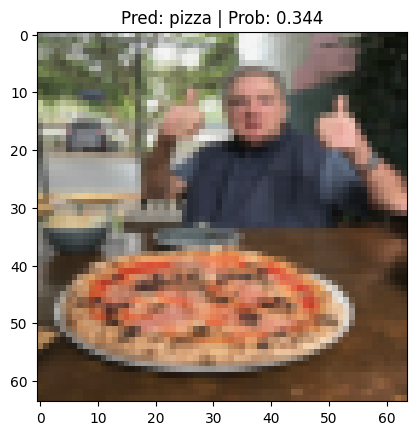

In [ ]:
# Pred on our custom image
pred_and_plot_image(model = model_1,
                    image_path = custom_image_path,
                    class_names = class_names,
                    transform = custom_image_transform,
                    device = device)